### Sanger Sequencing Check
# Input - each sample there is a sequence file and an ab1 file
# Aligned against DB of known sequences found in vectors at each stage 
Number 1 insert pooled oligo into pJR85 (intermediated) then an oligonucleotide insert (either CR3cs1-hU6 or CR2cs2-hU6)


![Text](../files/screenshot.png)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from Bio.Seq import Seq
import glob, os
import plotly
import plotly.graph_objects as go

# import plotly.io as pio
# pio.renderers.default = "notebook"


In [3]:
##Read in the sample metadata from sanger sequencing
sample_data=pd.read_excel("210928/P_210928_Helaine Graziele_Santos Vieira_4048703918_M001_Sample_Data.xlsx")
print(sample_data.head(n=1))

  sample ID               sample Name Repeats needed
0  EET--644  pJR85_Interm_Libpool_CL1             No


In [1]:
def createfasta(input_file, add_file, index_col="index",fasta_col="protospacer_53",output_file="./database.fa"):
    columns=[index_col,fasta_col]
    input_df=pd.read_excel(input_file, usecols=columns)
    add_df=pd.read_excel(add_file,header=None, names=columns)

    add_df[fasta_col]=add_df[fasta_col].str.upper()
    input_df=input_df.append(add_df, ignore_index=True)
    fasta=[]
    ##Create a fasta file for all of the files 
    for index,row in input_df.iterrows(): 
        fasta.append((">"+row[index_col]))
        fasta.append((row[fasta_col]))

    fasta_file = pd.DataFrame(fasta)
    fasta_file.to_csv(output_file,sep="\t",index=None, header=None)


def sanger_database(input_db_fasta):
    """""Input a folder and folder location with database location"""
    makedb_cmd="makeblastdb -dbtype nucl -in "+input_db_fasta
    #read in the different protospacers 
    os.system(makedb_cmd)

def prepend_line(file_name, line, dummy_file="tmp.fa"):
    """ Insert given string as a new line at the beginning of a file """
    # open original file in read mode and dummy file in write mode
    with open(file_name, 'r') as read_obj, open(dummy_file, 'w') as write_obj:
        # Write given line to the dummy file
        write_obj.write(line + '\n')
        # Read lines from original file one by one and append them to the dummy file
        for line in read_obj:
            write_obj.write(line)
    # remove original file
    # os.remove(file_name)
    # Rename dummy file as the original file
    # os.rename(dummy_file, file_name)


def sanger_blast(input_folder, folder_location, database_loc):
    """""Input a folder and folder location with database location"""
        #read in the different protospacers 

    ##first create a list of all the sequence files in a paticular path
    list_output=[]
    sanger_file_list=[]
    for file in os.listdir(folder_location):
        if file.endswith(".seq"):
            sanger_file_list.append(os.path.join("./",input_folder, file))

    #Edit each sanger sequencing file to change from seq to fasta file
    for file_name in sanger_file_list:
        ##Edit the sanger sequence to make it a fasta file
        name=(file_name.split("/")[2].split(".")[0])
    
        addline=">"+name
        prepend_line(file_name=file_name, line=addline)
        blastn_command='blastn -query tmp.fa -db '+database_loc+' -outfmt "10 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore" -out results.out -task blastn-short'
        os.system(blastn_command)
        # print(blastn_command)
        results=pd.read_csv("results.out", names=["qseqid","sseqid" ,"pident", "length" , "mismatch" , "gapopen" ,"qstart" ,"qend" ,"sstart" , "send", "evalue", "bitscore"])
        
        
        blastn_command='blastn -query tmp.fa -db '+database_loc+' -out results_display.out -task blastn-short'
        os.system(blastn_command)
        # print(blastn_command)
        list_output.append(results)

        append_commandline="cat results_display.out >> results_display_total.out"
        os.system(append_commandline)


    merged = pd.concat(list_output)
    return merged


def df_to_plotly(df):
    return {'z': df.values.tolist(),
            'x': df.columns.tolist(),
            'y': df.index.tolist() }
            
def plotly_create(input_dataframe,  save_file, value_column, index1="qseqid", index2="sseqid", title="Heatmap"):
    input_dataframe[value_column]=input_dataframe[value_column].astype(int)
    pivot_input_dataframe=pd.pivot_table(input_dataframe, values=value_column, index=index1, columns=index2)
    fig = go.Figure(
        data=go.Heatmap(df_to_plotly(pivot_input_dataframe)),
        layout=go.Layout(
    title=go.layout.Title(text=title)
        )
    )
    fig.show()
    plotly.offline.plot(fig, filename = save_file, auto_open=False)


def barchart_protospacer_count(input_df, startswith="RW", title="Bar Chart Showing the Number of Protospacers",savefigname="histogram"):
    input_df_prot=input_df[(input_df["sseqid"].str.startswith(startswith)) ]
    input_df_prot_len=input_df_prot[(input_df_prot["length"]>7)]
    input_df_prot_len_tst=input_df_prot_len[['qseqid','sseqid']].groupby("qseqid").count()
    # sns.histplot(input_df_prot_len_tst["sseqid"])
    input_df_prot_len_tst["sseqid"].value_counts().astype(int).sort_index(ascending=True).plot(kind = 'bar')
    plt.title(title)
    plt.xlabel("Number of Protospacers found in Sequence")
    save="./plotly/"+savefigname+".png"
    plt.savefig(save)


    

In [5]:
##Create a fasta, create database 
createfasta(input_file="./files/pilot_sgRNA_protospacersequences.xlsx" , add_file="./files/pJR85_dual_intermediante_addition_sequences.xlsx", output_file="./files/pool_oligo_library.fa")
sanger_database("./files/pool_oligo_library.fa")

sanger_merge=sanger_blast(input_folder="210928", folder_location="/Users/helenking/Desktop/Weatheritt_Lab/sanger-sequencing-alignment/210928", database_loc="./files/pool_oligo_library.fa")

##create a plot on the length
plotly_create(input_dataframe=sanger_merge, value_column="length", save_file="./plotly/210928_length.html", title="210928 Heatmap of the Length Aligned Between Sample Sanger and Reference Sequences")

###create a plot on the percentage align
# sanger_merge["percentage_align"]=sanger_merge["length"]/(sanger_merge["length"]+sanger_merge["mismatch"])
# plotly_create(input_dataframe=sanger_merge, value_column="percentage_align", save_file="./plotly/210928_percalign.html", title="210928 Heatmap of the Percentage Aligned Between Sample Sanger and Reference Sequences")

##get the longest alignment 
sanger_sub=sanger_merge.sort_values("length", ascending=False).groupby(["qseqid","sseqid"]).head(n=1)
sanger_sub=sanger_sub.sort_values("qstart")
sanger_sub["group_index"]=sanger_sub.groupby("qseqid").cumcount()

sanger_sub["group_index"]=sanger_sub["group_index"].astype(int)
##first mU6, protospacer, common_region, protospacerD, cr1
plotly_create(input_dataframe=sanger_sub, value_column="group_index", save_file="./plotly/210928_position.html", title="210928 Heatmap of the Position of Reference Sequences in Sanger Sequences - mU6, protospacer, common_region, protospacerD, cr1")
barchart_protospacer_count(sanger_sub, title="210928 Bar Chart Showing the Number of Protospacers", savefigname="210928_bar")


In [ ]:
sanger_subqs=sanger_sub[["qseqid","sseqid","qstart"]]
sanger_subqe=sanger_sub[["qseqid","sseqid","qend"]]

sanger_subqs.columns = sanger_subqe.columns
df_combined = pd.concat([sanger_subqs, sanger_subqe], axis=0, ignore_index=True)

df_combined["qseqid_short"]=df_combined["qseqid"].str.split("_Run_2021-09-29-15-39-51-667").str.get(0).str.split("_2021-09-29-15-40").str.get(0)


,qseqid,sseqid,qstart,qend
0,positive_control_pJR85_dual_intermediante,mU6,1,301
4,pJR85_Interm_Libpool_CL17_A05_2021-09-29-15-40...,mU6,4,37
3,pJR85_Interm_Libpool_mixed_B04_2021-09-29-15-4...,mU6,5,34
2,pJR85_Interm_Libpool_CL12_D04_2021-09-29-15-40...,mU6,6,36
3,pJR85_Interm_Libpool_CL2_B03_2021-09-29-15-40-...,mU6,6,38
...,...,...,...,...
24,pJR85_Interm_Libpool_CL20_D05_2021-09-29-15-40...,RW87_sgTP53_MP3,1031,1038
24,pJR85_Interm_Libpool_CL11_C04_2021-09-29-15-40...,RW87_sgTP53_MP3,1064,1071
25,pJR85_Interm_Libpool_CL11_C04_2021-09-29-15-40...,RW71_sgTP53_MP1,1064,1071
18,pJR85_Interm_Libpool_CL9_A04_2021-09-29-15-40-...,RW688_sgTP53_AP6,1095,1102


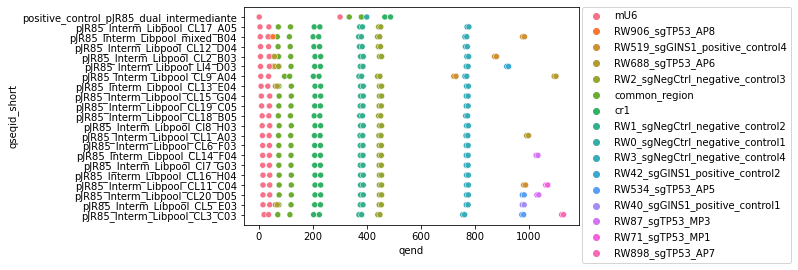

In [ ]:
sns.scatterplot(data=df_combined,y="qseqid_short", x="qend", hue="sseqid")
# plt.plot(df_combined["qend"], df_combined["sseqid"] )
# sns.lmplot(data=df_combined,y="qseqid_short", x="qend", hue="sseqid")
plt.legend(bbox_to_anchor=(1.01, 1), borderaxespad=0)



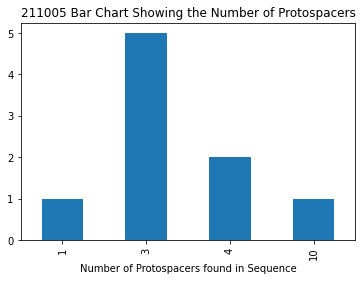

In [ ]:

createfasta(input_file="./files/pilot_sgRNA_protospacersequences.xlsx" , add_file="./files/pCRISPRi_dual_TP53AP2_additional_sequences.xlsx", output_file="./files/pool_oligo_library_crispri.fa")
sanger_database("./files/pool_oligo_library_crispri.fa")
sanger_merge=sanger_blast(input_folder="211005", folder_location="/Users/helenking/Desktop/Weatheritt_Lab/sanger-sequencing-alignment/211005", database_loc="./files/pool_oligo_library_crispri.fa")


sanger_merge["percentage_align"]=sanger_merge["length"]/(sanger_merge["length"]+sanger_merge["mismatch"])
plotly_create(input_dataframe=sanger_merge, value_column="length", save_file="./plotly/211005_length.html", title="211005 Heatmap of the Length Aligned Between Sample Sanger and Reference Sequences")
# plotly_create(input_dataframe=sanger_merge, value_column="percentage_align", save_file="./plotly/211005_length.html", title="211005 Heatmap of the Length Aligned Between Sample Sanger and Reference Sequences")

##first mU6, protospacer_C, common_region_short, protospacerD, cr3, hU6, commonr 2, protospacer D, cr1
sanger_sub=sanger_merge.sort_values("length", ascending=False).groupby(["qseqid","sseqid"]).head(n=1)
sanger_sub=sanger_sub.sort_values("qstart")
sanger_sub["group_index"]=sanger_sub.groupby("qseqid").cumcount()

sanger_sub["group_index"]=sanger_sub["group_index"].astype(int)
plotly_create(input_dataframe=sanger_sub, value_column="group_index", save_file="./plotly/211005_position.html", title="211005 Heatmap of the Position of Reference Sequences in \n Sanger Sequences -  mU6, protospacer_C, common_region1, protospacerD, cr3, hU6, common_region2, protospacer D, cr1")
barchart_protospacer_count(sanger_sub, title="211005 Bar Chart Showing the Number of Protospacers", savefigname="211005_bar")


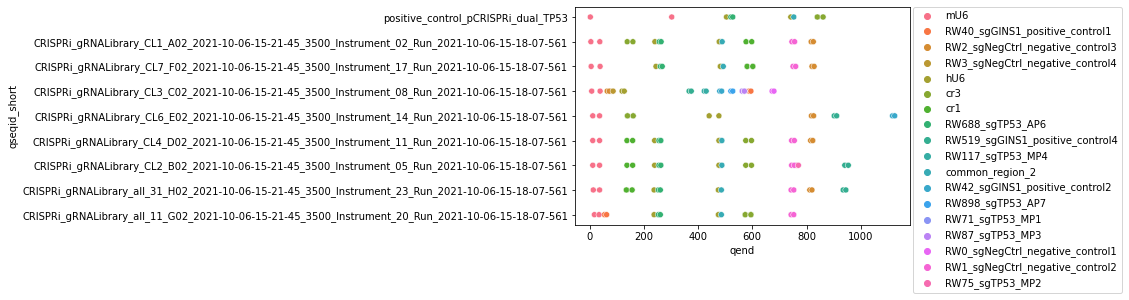

In [ ]:
sanger_subqs=sanger_sub[["qseqid","sseqid","qstart"]]
sanger_subqe=sanger_sub[["qseqid","sseqid","qend"]]

sanger_subqs.columns = sanger_subqe.columns
df_combined = pd.concat([sanger_subqs, sanger_subqe], axis=0, ignore_index=True)

df_combined["qseqid_short"]=df_combined["qseqid"].str.split("_Run_2021-09-29-15-39-51-667").str.get(0).str.split("_2021-09-29-15-40").str.get(0)

sns.scatterplot(data=df_combined,y="qseqid_short", x="qend", hue="sseqid")
# plt.plot(df_combined["qend"], df_combined["sseqid"] )
# sns.lmplot(data=df_combined,y="qseqid_short", x="qend", hue="sseqid")
plt.legend(bbox_to_anchor=(1.01, 1), borderaxespad=0)



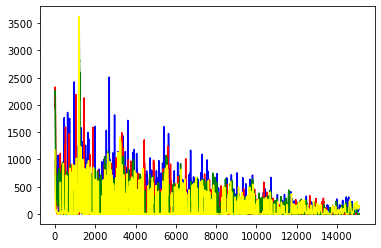

In [ ]:

record = SeqIO.read("210928/pJR85_Interm_Libpool_CL1_A03_2021-09-29-15-40-43_3500_Instrument_03_Run_2021-09-29-15-39-51-667.ab1", "abi")
list(record.annotations.keys())

from collections import defaultdict

channels = ["DATA9", "DATA10", "DATA11", "DATA12"]
trace = defaultdict(list)
for c in channels:
    trace[c] = record.annotations["abif_raw"][c]


plt.plot(trace["DATA9"], color="blue")
plt.plot(trace["DATA10"], color="red")
plt.plot(trace["DATA11"], color="green")
plt.plot(trace["DATA12"], color="yellow")
plt.show()


In [ ]:
##How many of the protospacers are aligned to the sequence
##7 bp of 500 protospacer sequecnes?


##Alignment on the correct position
##Matters is before or after the grey area


##You have base 

5) Test Transformation A series of test transformations will be performed to verify correct inserts and successful ligations with low background. Two serial transformations will be performed, as a single transformation of the ligation generates many mixed peaks during Sanger sequencing of colony PCR product. The goal is to achieve very sparse colonies for colony PCR ● Incubate O/N at 37ºC d) Pick the best plates for each sample. Sequence 10-20 colonies from each plate. The Sanger sequencing primer sequences are below; you can sequence directly from a colony PCR with the primer pair (expected size 804bp) or miniprep the plasmids first. Either primer will allow you to sequence through the sgRNA protospacer and adjacent restriction sites. To verify your test transformation: • Align the Sanger sequence output to the library vector map in your favorite cloning software (e.g. ApE) to ensure the sgRNAs were cloned properly • The 19bp corresponding to the unique protospacer sequence should not align it the vector. Search for this sequence in the list of sgRNAs in your oligo pool. If 60-80% of the sequences match to the correct library (you will likely see some oligo synthesis errors and sequencing errors), it is safe to proceed with the large-scale transformation. o No sequences should perfectly align to the library vector at the protospacer region. This would indicate that the parental vector was incompletely digested and the stuffer sequence is present in the library. o It is also extremely unlikely that any sgRNA appears multiple times in a random set of 10 colonies. Repeated sequences are an indication that one species from the oligo pool is very overrepresented (edited) 



I’ve done very different baterial transformation but I achived the same thing sparse colonies to do colony PCR of 20 colonies (all of them have the band ~ 804) then I did miniprep of the same colonies and submit for sanger sequencing together with the total colonies I’ve washed out with LB broth from the agar plates I had



CR1 sequence and very end of mU6/beginning of photospacer A 

mU6_fwd primer sequence CAGCACAAAAGGAAACTCACC